# Improved Baseline Model

This updated pipeline introduces some strcutural changes to how the model calculates errors and processes inputs, aiming to be optimized for small objects and class imbalances.

The main changes include:
- Changing the bounding box loss from MSE to GIoU, which evaluates the spatial intersection more effectively, especially for small objects. Using this metric, if the predicted box fails to touch the target object, the penalty remains at its maximum value, driving the optimizer to make precise corrections.
- On the first version, in order to compute the bounding box loss, we were multiplying the predicted boxes by a mask that zeroed out the background samples. This approach kept the output at zero for empty images, but the structural loss gradients were still heavily diluted by the massive volume of empty backgrounds. In the updated version, we restrict the bounding box loss calculation strictly to batch samples containing actual target objects (classes > 0). If an entire training batch consists solely of empty baggage, the box regressor skips backpropagation entirely, preventing empty background spaces from damaging feature localization.
- We also increased the weight of the bounding box loss in the total loss calculation. (total_loss = loss_cls + 4.0 * loss_bbox) This change forces the optimizer to prioritize tight bounding box placement above all else, especially when the model fails to bound a small object.
- We applied differential learning rates to the backbone and the new heads. The ResNet18 backbone updates at an extremely slow pace (lr=1e-5), allowing its existing edge and texture filters to gently adapt to the X-ray images domain without forgetting general shapes. The new classification and regression heads maintain a normal pace (lr=1e-3) to quickly localize out and separate the 6 target classes.
- Data augmentation is now applied in a way the images and bounding boxes are transformed in alignment.
- Different class weights are applied to the classification loss, relaxing the background penalty slightly and sharply boosting the error penalties for minority classes.

 ## 1. imports

In [1]:
%uv pip install ultralytics scikit-learn seaborn opencv-python kagglehub torchmetrics[detection]


Using Python 3.12.6 environment at: /usr/local
Resolved 63 packages in 354ms
⠙ Preparing packages... (0/8)
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------     0 B/28.27 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------ 14.83 KiB/28.27 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------ 14.83 KiB/28.27 KiB
pycocotools ------------------------------     0 B/402.04 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------ 14.83 KiB/28.27 KiB
pycocotools ------------------------------ 14.83 KiB/402.04 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------ 14.83 KiB/28.27 KiB
pycocotools ------------------------------ 30.83 KiB/402.04 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------------------------------ 14.83 KiB/28.27 KiB
pycocotools ------------------------------ 46.83 KiB/402.04 KiB
⠙ Preparing packages... (0/8)
ultralytics-thop ------

In [16]:
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import shutil
import time
import yaml

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torchvision import tv_tensors
from torchvision.transforms import ToTensor
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.ops import generalized_box_iou_loss
from PIL import Image
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from tqdm.notebook import tqdm


 ## 2. download and explore the dataset

In [3]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")
print("Path to dataset files:", path)

# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")


100%|███████████████████████████████████████████████████████████████████████| 133M/133M [00:04<00:00, 30.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1
Number of training images: 6181
Number of training labels: 6181


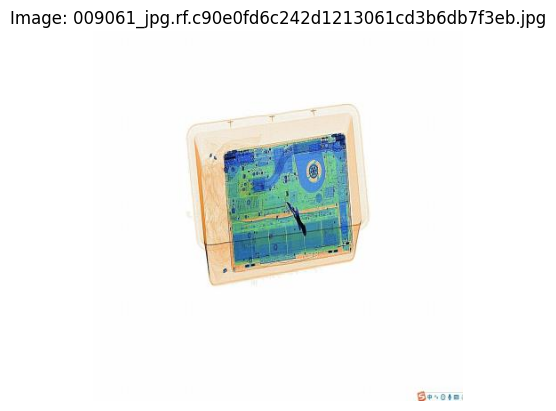

Contents of label file 009061_jpg.rf.c90e0fd6c242d1213061cd3b6db7f3eb.txt:
2 0.5576923076923077 0.515625 0.08052884615384616 0.13221153846153846


In [4]:
# select an image and its corresponding label file to inspect
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

print(f"Contents of label file {label_file}:\n{label_contents}")


In [5]:
def draw_yolo_bbox(image_path, label_data):
    # read image, convert to rgb and get dimensions
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    for line in label_data.splitlines():
        # take the label data and convert to float
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")

        # compute the bounding box coordinates
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)

        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))

        # draw the bounding box on the image
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Prohibited Objects")
    plt.axis('off')
    plt.show()


Label data - x: 0.5576923076923077, y: 0.515625, w: 0.08052884615384616, h: 0.13221153846153846


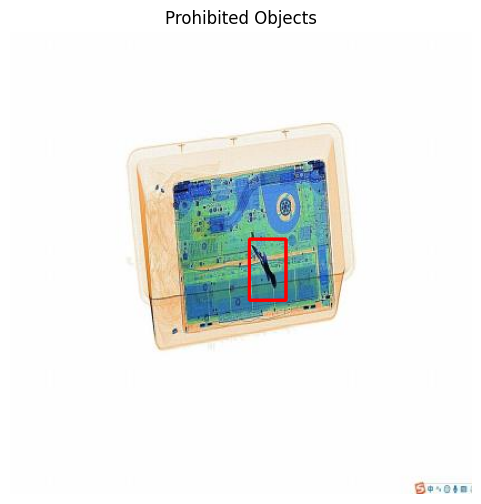

In [6]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)


 ## 3. image preprocessing

In [ ]:
def preprocess_xray(img):
    # clahe (contrast limited adaptive histogram equalization)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # sharpening the image
    gaussian_blur = cv2.GaussianBlur(img_clahe, (9, 9), 10.0)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, gaussian_blur, -0.5, 0)

    return img_sharp

In [8]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# save processed images in local colab storage
train_images_proc = "/content/dataset_processed/train/images"
val_images_proc = "/content/dataset_processed/valid/images"
test_images_proc = "/content/dataset_processed/test/images"

print("Preprocessing images...")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")


Preprocessing images...
Preprocessing completed in 64.89 seconds


 ## 4. dataset statistics & pytorch dataset setup

In [9]:
def calculate_dataset_mean_and_std(folder_path):
    img_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not img_files:
        raise ValueError(f"No images found in path: {folder_path}")

    to_tensor = ToTensor()
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    total_pixels = 0

    for img_name in img_files:
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path).convert("RGB")
        tensor_img = to_tensor(img)

        num_pixels = tensor_img.size(1) * tensor_img.size(2)
        total_pixels += num_pixels

        channels_sum += tensor_img.sum(dim=[1, 2])
        channels_squared_sum += (tensor_img ** 2).sum(dim=[1, 2])

    dataset_mean = channels_sum / total_pixels
    dataset_std = torch.sqrt((channels_squared_sum / total_pixels) - (dataset_mean ** 2))

    return dataset_mean.tolist(), dataset_std.tolist()

XRAY_MEAN, XRAY_STD = calculate_dataset_mean_and_std(train_images_proc)
print(f"Calculated Mean: {XRAY_MEAN}\nCalculated Std: {XRAY_STD}")


Calculated Mean: [0.8954328894615173, 0.879461407661438, 0.8448767066001892]
Calculated Std: [0.21848894655704498, 0.22072364389896393, 0.2670595943927765]


In [19]:
class XRayDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        # initialize the dataset with the directory paths and transformations
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # load the image and corresponding label file
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(self.labels_dir, label_name)

        class_id = 0
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                lines = f.readlines()
                if lines:
                    data = lines[0].split()
                    class_id = int(data[0]) + 1
                    bbox = [float(x) for x in data[1:5]]

        # convert to native tensors so v2 transforms can process them simultaneously
        image = T.functional.to_image(image)
        image = T.functional.to_dtype(image, torch.float32, scale=True)
        
        # wrap in native torchvision bounding boxes to apply coordinated geometric data augmentation
        target_boxes = tv_tensors.BoundingBoxes(
            [bbox], format="CXCYWH", canvas_size=image.shape[-2:]
        )

        if self.transform:
            image, target_boxes = self.transform(image, target_boxes)

        # extract the plain subclass tensor to match training contracts
        final_bbox = target_boxes.as_subclass(torch.Tensor).squeeze(0)
        
        # manual normalization step after geometry operations
        image = T.functional.normalize(image, mean=XRAY_MEAN, std=XRAY_STD)

        return image, torch.tensor(class_id, dtype=torch.long), final_bbox


 ## 5. baseline model architecture

In [11]:
class XRayBaselineModel(nn.Module):
    def __init__(self, num_classes):
        super(XRayBaselineModel, self).__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # classification head for background vs prohibited item
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # dropout to avoid early overfitting
            nn.Linear(128, num_classes)
        )

        # regression head for bounding box coordinates (x_center, y_center, width, height)
        self.box_regressor = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        class_preds = self.classifier(features)
        bbox_preds = self.box_regressor(features)
        return class_preds, bbox_preds


 ## 6. train and evaluate functions

In [ ]:
def cxcywh_to_xyxy(boxes):
    # helper helper to convert center coordinates to bounding corners for generalized iou calculation
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    xmin = cx - (w / 2)
    ymin = cy - (h / 2)
    xmax = cx + (w / 2)
    ymax = cy + (h / 2)
    return torch.stack([xmin, ymin, xmax, ymax], dim=1)

def train_and_save_baseline(model, train_loader, val_loader, epochs=15, device="cuda", weights_path="best_baseline.pth"):
    model = model.to(device)
    
    # balancing focus towards objects instead of background classification
    pesos = torch.tensor([1.0, 2.0, 4.5, 4.5, 4.5, 5.0]).to(device)
    criterion_cls = nn.CrossEntropyLoss(weight=pesos)
    
    # differential learning rates for fine-tuning the backbone features smoothly
    optimizer = torch.optim.Adam([
        {"params": model.backbone.parameters(), "lr": 1e-5},
        {"params": model.classifier.parameters(), "lr": 1e-3},
        {"params": model.box_regressor.parameters(), "lr": 1e-3}
    ])

    best_val_loss = float('inf')
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_map50": [], "val_map50": []
    }

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        map_metric.reset()

        train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
        for images, classes, bboxes in train_bar:
            images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)

            optimizer.zero_grad()
            cls_preds, bbox_preds = model(images)

            loss_cls = criterion_cls(cls_preds, classes)
            
            # prioritize small objects by computing bbox loss exclusively when objects are present
            is_object = (classes > 0)
            if is_object.any():
                pred_boxes_obj = cxcywh_to_xyxy(bbox_preds[is_object])
                target_boxes_obj = cxcywh_to_xyxy(bboxes[is_object])
                # giou loss enforces overlap independent of relative bounding box pixel area sizes
                loss_bbox = generalized_box_iou_loss(pred_boxes_obj, target_boxes_obj).mean()
            else:
                loss_bbox = torch.tensor(0.0).to(device)

            # scale regression loss weighting to push structural modifications onto spatial anchors
            total_loss = loss_cls + 4.0 * loss_bbox
            total_loss.backward()
            optimizer.step()

            train_loss += total_loss.item() * images.size(0)
            
            preds_class = cls_preds.argmax(dim=1)
            train_correct += (preds_class == classes).sum().item()

            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                if preds_class[i] > 0:
                    preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds_class[i].unsqueeze(0).cpu()}]
                    target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                    map_metric.update(preds_dict, target_dict)

            current_acc = (preds_class == classes).float().mean().item()
            train_bar.set_postfix(loss=total_loss.item(), bbox_loss=loss_bbox.item())

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        
        try: train_map50 = map_metric.compute()["map_50"].item()
        except: train_map50 = 0.0

        # validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        map_metric.reset()

        val_bar = tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", leave=False)
        with torch.no_grad():
            for images, classes, bboxes in val_bar:
                images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)
                cls_preds, bbox_preds = model(images)

                loss_cls = criterion_cls(cls_preds, classes)
                
                is_object_val = (classes > 0)
                if is_object_val.any():
                    pred_boxes_obj = cxcywh_to_xyxy(bbox_preds[is_object_val])
                    target_boxes_obj = cxcywh_to_xyxy(bboxes[is_object_val])
                    loss_bbox = generalized_box_iou_loss(pred_boxes_obj, target_boxes_obj).mean()
                else:
                    loss_bbox = torch.tensor(0.0).to(device)

                total_loss = loss_cls + 4.0 * loss_bbox
                val_loss += total_loss.item() * images.size(0)
                
                preds_class = cls_preds.argmax(dim=1)
                val_correct += (preds_class == classes).sum().item()

                scores = torch.softmax(cls_preds, dim=1)
                for i in range(images.size(0)):
                    if preds_class[i] > 0:
                        preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds_class[i].unsqueeze(0).cpu()}]
                        target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                        map_metric.update(preds_dict, target_dict)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        try: val_map50 = map_metric.compute()["map_50"].item()
        except: val_map50 = 0.0
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_map50"].append(train_map50)
        history["val_map50"].append(val_map50)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss (T/V): {train_loss:.4f} / {val_loss:.4f} | Acc (T/V): {train_acc:.2%} / {val_acc:.2%} | mAP50 (T/V): {train_map50:.4f} / {val_map50:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), weights_path)
            print(f"Saved new best model")

    print("\nTraining finished.")
    return history


In [13]:
def evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device="cuda"):
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"Weights successfully loaded from '{weights_path}' for evaluation.\n")
    else:
        print(f"No weights found at '{weights_path}'. Evaluating with current weights.")

    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')
    
    with torch.no_grad():
        for images, classes, bboxes in test_loader:
            images = images.to(device)
            cls_preds, bbox_preds = model(images)
            preds = torch.argmax(cls_preds, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(classes.numpy())
            
            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                if preds[i] > 0:
                    preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds[i].unsqueeze(0).cpu()}]
                    target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                    map_metric.update(preds_dict, target_dict)
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    
    try: test_map50 = map_metric.compute()['map_50'].item()
    except: test_map50 = 0.0
    
    print("==================================================")
    print("         AVERAGE TEST MACRO METRICS")
    print("==================================================")
    print(f"Precisión General (Precision): {precision:.4f}")
    print(f"Sensibilidad General (Recall):    {recall:.4f}")
    print(f"Detección Final mAP50 (Test):     {test_map50:.4f}")
    print("==================================================\n")
    
    target_names = ['Background', 'Object 0', 'Object 1', 'Object 2', 'Object 3', 'Object 4'] 
    
    print("==================================================")
    print("            CLASSIFICATION REPORT              ")
    print("==================================================")
    print(classification_report(all_targets, all_preds, labels=range(len(target_names)), target_names=target_names, zero_division=0))

    print("==================================================")
    print("              CONFUSION MATRIX                 ")
    print("==================================================")
    cm = confusion_matrix(all_targets, all_preds)
    print(cm)
    print("==================================================")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de Confusión - Baseline Test')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.show()

    return all_targets, all_preds


In [14]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, history["val_loss"], 'r-s', label='Val Loss', markersize=4)
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], 'b-o', label='Train Accuracy', markersize=4)
    plt.plot(epochs, history["val_acc"], 'r-s', label='Val Accuracy', markersize=4)
    plt.title('Classification Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_map50"], 'b-o', label='Train mAP50', markersize=4)
    plt.plot(epochs, history["val_map50"], 'r-s', label='Val mAP50', markersize=4)
    plt.title('Object Detection mAP @ IoU=0.50')
    plt.xlabel('Epochs')
    plt.ylabel('mAP50')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


 ## 7. execution pipeline

Current execution device: cuda

--- Epoch 1/15 ---


Training Epoch 1:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 1:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [1/15] | Loss (T/V): 9.4904 / 5.6893 | Acc (T/V): 22.75% / 22.37% | mAP50 (T/V): 0.0000 / 0.0000
Saved new best model

--- Epoch 2/15 ---


Training Epoch 2:   0%|          | 0/194 [00:00<?, ?it/s]

...

Validating Epoch 14:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [14/15] | Loss (T/V): 8.8397 / 5.3773 | Acc (T/V): 62.51% / 62.00% | mAP50 (T/V): 0.0000 / 0.0000

--- Epoch 15/15 ---


Training Epoch 15:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 15:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [15/15] | Loss (T/V): 8.8132 / 4.9901 | Acc (T/V): 63.92% / 63.59% | mAP50 (T/V): 0.0000 / 0.0000
Saved new best model

Training finished.


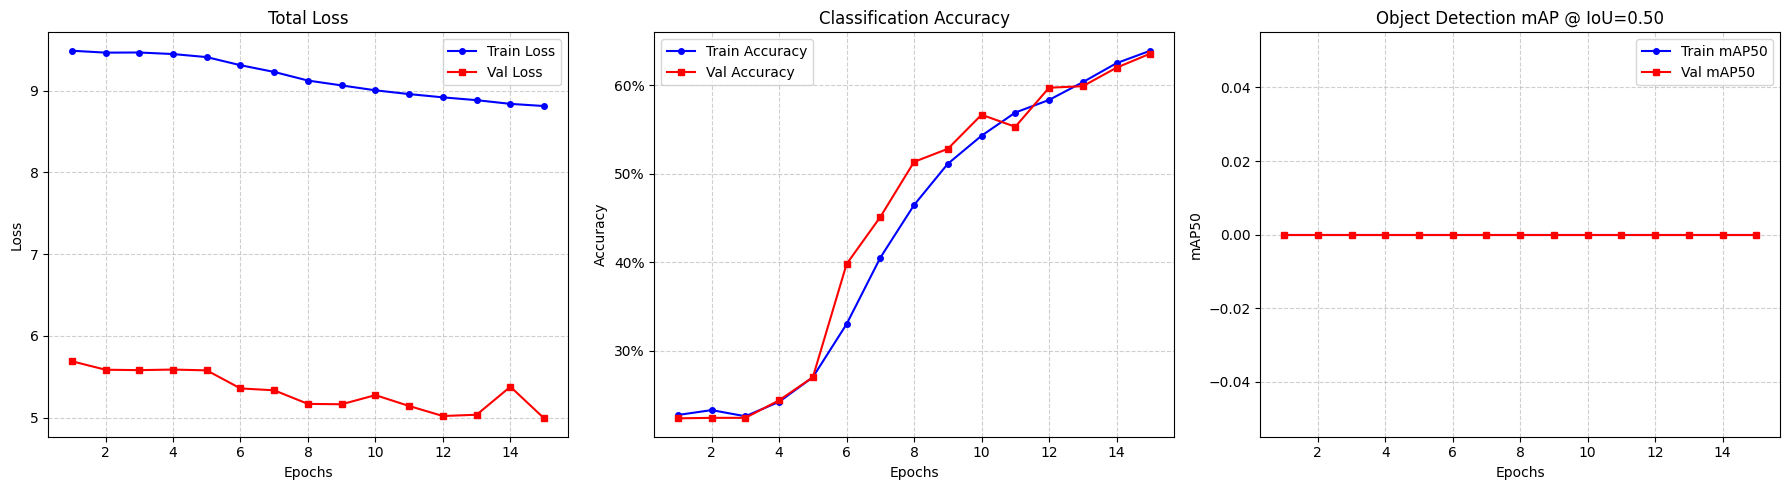

Weights successfully loaded from 'best_baseline.pth' for evaluation.

         AVERAGE TEST MACRO METRICS
Precisión General (Precision): 0.6355
Sensibilidad General (Recall):    0.6105
Detección Final mAP50 (Test):     0.0000

            CLASSIFICATION REPORT              
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00         0
    Object 0       0.83      0.63      0.72       166
    Object 1       0.61      0.65      0.63       193
    Object 2       0.43      0.28      0.34       118
    Object 3       0.51      0.66      0.57       203
    Object 4       0.80      0.83      0.81       203

    accuracy                           0.64       883
   macro avg       0.53      0.51      0.51       883
weighted avg       0.65      0.64      0.64       883

              CONFUSION MATRIX                 
[[105  17   8  32   4]
 [  9 126   5  35  18]
 [  3  17  33  55  10]
 [ 10  25  24 134  10]
 [  0  20   7   8 168]]


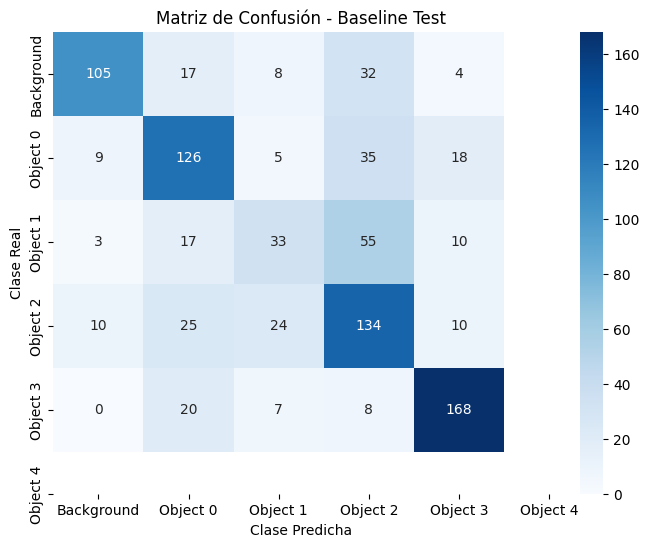

In [20]:
# spatial transformations to prevent spatial position memorization
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15)
])

val_test_transform = None 

# instantiate datasets
train_dataset = XRayDataset(images_dir=train_images_proc, labels_dir=os.path.join(train_path, "labels"), transform=train_transform)
val_dataset = XRayDataset(images_dir=val_images_proc, labels_dir=os.path.join(val_path, "labels"), transform=val_test_transform)
test_dataset = XRayDataset(images_dir=test_images_proc, labels_dir=os.path.join(test_path, "labels"), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current execution device: {device}")

model = XRayBaselineModel(num_classes=6)

# run training across 15 epochs to let the network specialize on the small features
metrics_history = train_and_save_baseline(model, train_loader, val_loader, epochs=15, device=device, weights_path="best_baseline.pth")

# plot historical trends
plot_training_curves(metrics_history)

# final evaluation metrics execution
targets, preds = evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device=device)

In [21]:
def visualize_predictions(model, dataset, num_samples=3, device="cuda"):
    """
    plots a grid of images showing ground truth bounding boxes in green 
    and model predictions in red to inspect performance visually.
    """
    model.eval()
    model.to(device)
    
    # target labels mapping for the titles
    target_names = ['background', 'object 0', 'object 1', 'object 2', 'object 3', 'object 4']
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(8, 5 * num_samples))
    if num_samples == 1:
        axes = [axes]
        
    for i in range(num_samples):
        # pick a random sample from the dataset
        idx = np.random.randint(0, len(dataset))
        image_tensor, target_class, target_bbox = dataset[idx]
        
        # model prediction inference
        with torch.no_grad():
            # add batch dimension and move to device
            input_tensor = image_tensor.unsqueeze(0).to(device)
            cls_pred, bbox_pred = model(input_tensor)
            
            pred_class = torch.argmax(cls_pred, dim=1).item()
            pred_bbox = bbox_pred.squeeze(0).cpu().numpy()
            
        # denormalize image for correct rgb matplotlib display
        img = image_tensor.permute(1, 2, 0).numpy()
        img = img * np.array(XRAY_STD) + np.array(XRAY_MEAN)
        img = np.clip(img, 0, 1)
        
        # get pixel dimensions
        H, W, _ = img.shape
        
        # open canvas to draw rectangles via opencv safely on a copy
        img_canvas = (img.copy() * 255).astype(np.uint8)
        
        # draw ground truth if it is an actual object (class > 0)
        if target_class > 0:
            cx, cy, w, h = target_bbox.numpy()
            xmin = int((cx - w/2) * W)
            ymin = int((cy - h/2) * H)
            xmax = int((cx + w/2) * W)
            ymax = int((cy + h/2) * H)
            cv2.rectangle(img_canvas, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3) # green box
            
        # draw model prediction if it infers an actual object (class > 0)
        if pred_class > 0:
            cx, cy, w, h = pred_bbox
            xmin = int((cx - w/2) * W)
            ymin = int((cy - h/2) * H)
            xmax = int((cx + w/2) * W)
            ymax = int((cy + h/2) * H)
            cv2.rectangle(img_canvas, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3) # red box

        # render results on subplot
        axes[i].imshow(img_canvas)
        axes[i].axis("off")
        
        title_text = (
            f"sample {idx}\n"
            f"gt: {target_names[target_class]} (green)\n"
            f"pred: {target_names[pred_class]} (red)"
        )
        axes[i].set_title(title_text, fontsize=12, loc="left")
        
    plt.tight_layout()
    plt.show()

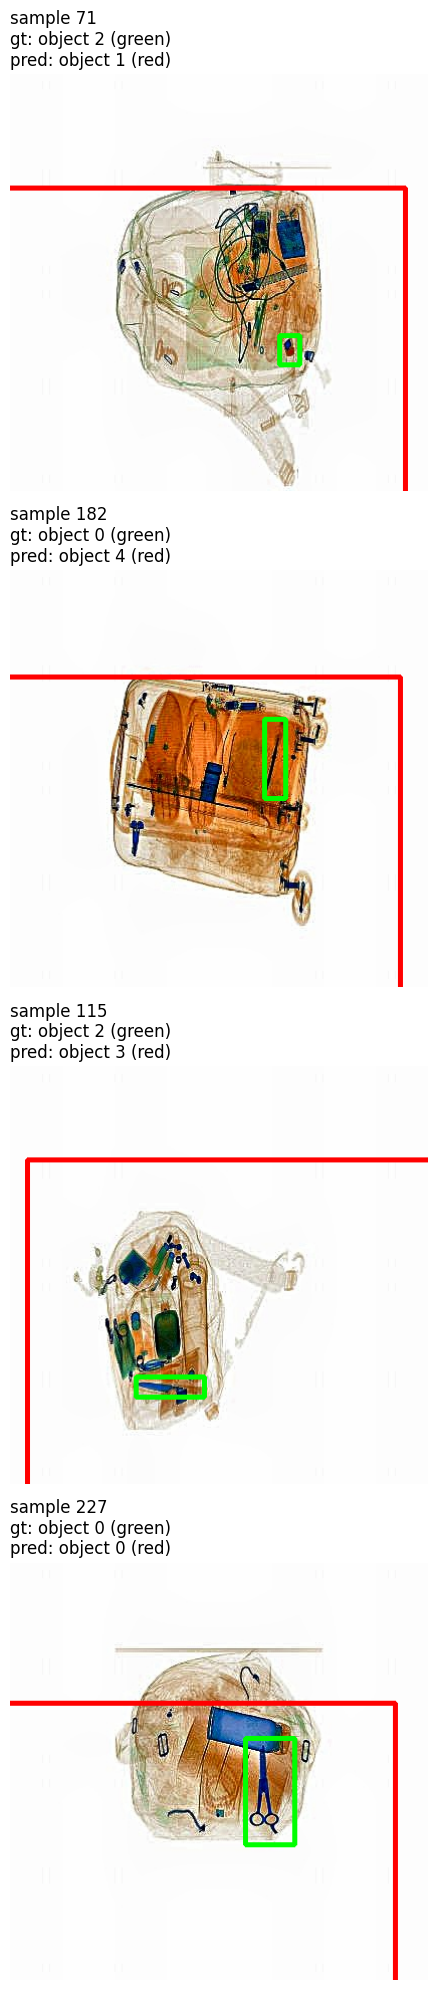

In [24]:
# visual verification of training samples
visualize_predictions(model=model, dataset=test_dataset, num_samples=4, device=device)

Classification is better, but the model is still not learning to localize the objects :(